# 01_eda_lesions.ipynb — EDA + auditoria do dataset bruto

## Objetivo
Entender o dataset bruto de lesões cutâneas, auditar a correspondência entre CSV e arquivos no disco e inferir um contrato inicial de schema para os próximos notebooks.

## Escopo
- Ler `GroundTruth.csv`
- Normalizar nomes de colunas
- Inferir `image_col`, `mask_col`, `label_cols`, `meta_cols`, `mode` e `target_encoding`
- Auditar CSV ↔ imagens ↔ máscaras por stem
- Medir duplicatas, ausências e cobertura
- Fazer EDA mínima de labels e metadados
- Executar sanity visual com imagens e máscaras
- Salvar artefatos:
  - `data/processed/eda_schema_inferido.json`
  - `data/processed/eda_auditoria_arquivos.csv`
  - `data/processed/eda_resumo.csv`

## Outputs esperados
- contrato inicial do schema
- auditoria de arquivos
- resumo executivo da etapa
- conclusão explícita para o Notebook 02

## Regras desta versão
- um único fluxo oficial
- inferência rastreável
- paths relativos ao repositório
- sem depender de suposição manual sobre nome de coluna de imagem

In [1]:
# =========================
# 01_eda_lesions.ipynb — Célula 01
# Setup + imports + seed
# =========================

from __future__ import annotations

import os
import re
import json
import csv
import random
from datetime import datetime, timezone
from pathlib import Path
from typing import Dict, List, Optional, Tuple

missing = []
try:
    import numpy as np
except Exception:
    missing.append("numpy")
try:
    import pandas as pd
except Exception:
    missing.append("pandas")
try:
    from PIL import Image
except Exception:
    missing.append("pillow")
try:
    import matplotlib.pyplot as plt
except Exception:
    missing.append("matplotlib")

if missing:
    raise RuntimeError(
        "Dependências ausentes: "
        + ", ".join(missing)
        + "\nInstale com:\n  pip install "
        + " ".join(missing)
    )

REPRO_SEED = 42
random.seed(REPRO_SEED)
np.random.seed(REPRO_SEED)
os.environ["PYTHONHASHSEED"] = str(REPRO_SEED)

print("OK — imports carregados.")
print("Seed fixa:", REPRO_SEED)

OK — imports carregados.
Seed fixa: 42


In [2]:
# =========================
# 01_eda_lesions.ipynb — Célula 02
# PROJECT_ROOT + paths oficiais
# =========================

def _looks_like_repo_root(p: Path) -> bool:
    return (
        (p / "data" / "raw" / "lesions" / "GroundTruth.csv").exists()
        and (p / "data" / "raw" / "lesions" / "images").exists()
        and (p / "data" / "processed").exists()
    )

def _normalize_repo_candidate(p: Path) -> Optional[Path]:
    p = p.expanduser().resolve()
    if _looks_like_repo_root(p):
        return p
    if _looks_like_repo_root(p / "pimple"):
        return (p / "pimple").resolve()
    return None

def find_project_root_robust() -> Path:
    env_root = os.environ.get("PIMPLE_PROJECT_ROOT") or os.environ.get("PROJECT_ROOT")
    if env_root:
        normalized = _normalize_repo_candidate(Path(env_root))
        if normalized is not None:
            return normalized
        raise FileNotFoundError(
            f"[ERRO] Env PROJECT_ROOT/PIMPLE_PROJECT_ROOT aponta para {env_root}, "
            "mas não parece ser a raiz do repo pimple nem o diretório pai que contém a pasta pimple."
        )

    start = Path.cwd().resolve()
    for base in [start, *start.parents]:
        normalized = _normalize_repo_candidate(base)
        if normalized is not None:
            return normalized

    raise FileNotFoundError(
        "Não consegui localizar a raiz do repositório pimple.\n"
        "Dica: defina os.environ['PIMPLE_PROJECT_ROOT'] = r'CAMINHO_PARA_O_REPO_PIMPLE' e rode de novo."
    )

PROJECT_ROOT = find_project_root_robust()

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "lesions"
GT_CSV = RAW_DIR / "GroundTruth.csv"
IMAGES_DIR = RAW_DIR / "images"
MASKS_DIR = RAW_DIR / "masks"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

assert GT_CSV.exists(), f"GroundTruth.csv não existe: {GT_CSV}"
assert IMAGES_DIR.exists(), f"IMAGES_DIR não existe: {IMAGES_DIR}"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("GT_CSV      :", GT_CSV)
print("IMAGES_DIR  :", IMAGES_DIR)
print("MASKS_DIR   :", MASKS_DIR, "| existe?", MASKS_DIR.exists())
print("PROCESSED   :", PROCESSED_DIR)

PROJECT_ROOT: C:\Users\win\Documents\GitHub\pimple
GT_CSV      : C:\Users\win\Documents\GitHub\pimple\data\raw\lesions\GroundTruth.csv
IMAGES_DIR  : C:\Users\win\Documents\GitHub\pimple\data\raw\lesions\images
MASKS_DIR   : C:\Users\win\Documents\GitHub\pimple\data\raw\lesions\masks | existe? True
PROCESSED   : C:\Users\win\Documents\GitHub\pimple\data\processed


In [3]:
# =========================
# 01_eda_lesions.ipynb — Célula 03
# Leitura do CSV + normalização
# =========================

def sniff_csv_sep(path: Path, default: str = ",") -> str:
    try:
        sample = path.read_text(encoding="utf-8", errors="ignore")[:4096]
        dialect = csv.Sniffer().sniff(sample, delimiters=[",", ";", "\t", "|"])
        return dialect.delimiter
    except Exception:
        return default

def normalize_colname(c: str) -> str:
    c = c.strip().lower()
    c = re.sub(r"\s+", "_", c)
    c = re.sub(r"[^a-z0-9_]+", "", c)
    c = re.sub(r"_+", "_", c).strip("_")
    return c

sep = sniff_csv_sep(GT_CSV, default=",")
df_raw = pd.read_csv(GT_CSV, sep=sep, low_memory=False)

df = df_raw.copy()
df.columns = [normalize_colname(c) for c in df.columns]

print("CSV lido com sep =", repr(sep))
print("df_raw.shape:", df_raw.shape)
print("df.shape    :", df.shape)
print("Primeiras colunas:", df.columns.tolist()[:20])
display(df.head(3))

CSV lido com sep = ','
df_raw.shape: (10015, 8)
df.shape    : (10015, 8)
Primeiras colunas: ['image', 'mel', 'nv', 'bcc', 'akiec', 'bkl', 'df', 'vasc']


,image,mel,nv,bcc,akiec,bkl,df,vasc
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# =========================
# 01_eda_lesions.ipynb — Célula 04
# Inferência de schema (rastreável)
# =========================

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
MASK_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

def looks_like_filename(x: object, exts: set[str]) -> bool:
    if not isinstance(x, str):
        return False
    x = x.strip()
    if len(x) < 3:
        return False
    p = Path(x)
    return p.suffix.lower() in exts

def col_filename_score(series: pd.Series, exts: set[str]) -> float:
    s = series.dropna()
    if len(s) == 0:
        return 0.0
    return float(s.astype(str).map(lambda v: looks_like_filename(v, exts=exts)).mean())

def detect_image_col_by_filename(df: pd.DataFrame) -> Tuple[Optional[str], List[Tuple[str, float]]]:
    scores = []
    for c in df.columns:
        sc = col_filename_score(df[c], IMG_EXTS)
        if sc > 0:
            scores.append((c, sc))
    scores.sort(key=lambda x: x[1], reverse=True)
    return (scores[0][0] if scores else None), scores[:10]

def detect_mask_col_by_filename(df: pd.DataFrame) -> Tuple[Optional[str], List[Tuple[str, float]]]:
    scores = []
    for c in df.columns:
        sc = col_filename_score(df[c], MASK_EXTS)
        name_bonus = 0.15 if ("mask" in c or "seg" in c) else 0.0
        sc2 = min(1.0, sc + name_bonus)
        if sc2 > 0:
            scores.append((c, float(sc2)))
    scores.sort(key=lambda x: x[1], reverse=True)
    return (scores[0][0] if scores else None), scores[:10]

def is_binary_like(series: pd.Series) -> bool:
    s = series.dropna()
    if len(s) == 0:
        return False
    v = pd.to_numeric(s, errors="coerce").dropna()
    if len(v) == 0:
        return False
    uniq = set(v.unique().tolist())
    return uniq.issubset({0, 1})

image_col_by_name, image_candidates = detect_image_col_by_filename(df)
mask_col_by_name, mask_candidates = detect_mask_col_by_filename(df)

exclude_base = set()
if image_col_by_name:
    exclude_base.add(image_col_by_name)
if mask_col_by_name:
    exclude_base.add(mask_col_by_name)

binary_cols = [c for c in df.columns if c not in exclude_base and is_binary_like(df[c])]

mode = "unknown"
target_encoding = None
label_cols: List[str] = []

if len(binary_cols) >= 2:
    X = df[binary_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)
    row_sum = X.sum(axis=1)

    ratio_eq_1 = float((row_sum == 1).mean())
    ratio_in_01 = float(row_sum.isin([0, 1]).mean())

    if ratio_eq_1 >= 0.90 and ratio_in_01 >= 0.98:
        mode = "single_label"
        target_encoding = "one_hot_multiclass"
        label_cols = binary_cols
    else:
        mode = "multi_label"
        target_encoding = "multi_label_binary_cols"
        label_cols = binary_cols

# meta_cols = tudo que não for imagem, máscara ou label
exclude_meta = set(label_cols)
if image_col_by_name:
    exclude_meta.add(image_col_by_name)
if mask_col_by_name:
    exclude_meta.add(mask_col_by_name)

meta_cols = [c for c in df.columns if c not in exclude_meta]

schema = {
    "created_at": datetime.now(timezone.utc).isoformat(),
    "project_root": str(PROJECT_ROOT),
    "raw": {
        "raw_dir": str(RAW_DIR),
        "images_dir": str(IMAGES_DIR),
        "masks_dir": str(MASKS_DIR),
        "groundtruth_csv": str(GT_CSV),
    },
    "columns": {
        "image_col": image_col_by_name,
        "mask_col": mask_col_by_name,
        "mode": mode,
        "target_encoding": target_encoding,
        "label_cols": label_cols,
        "meta_cols": meta_cols,
        "all_columns": df.columns.tolist(),
    },
    "diagnostics": {
        "binary_cols_count": int(len(binary_cols)),
        "image_col_filename_candidates_top10": image_candidates,
        "mask_col_filename_candidates_top10": mask_candidates,
    },
    "notes": {
        "image_col_rule": "A seleção final de image_col pode ser refinada na próxima célula por match de stem com o diretório images/.",
        "mode_rule": "Se colunas binárias somam 1 na maioria das linhas => single_label one_hot_multiclass.",
    },
}

print("Schema preliminar:")
print("image_col (filename-based):", image_col_by_name)
print("mask_col  (filename-based):", mask_col_by_name)
print("mode:", mode)
print("target_encoding:", target_encoding)
print("label_cols:", label_cols)
print("meta_cols_count:", len(meta_cols))

Schema preliminar:
image_col (filename-based): None
mask_col  (filename-based): None
mode: single_label
target_encoding: one_hot_multiclass
label_cols: ['mel', 'nv', 'bcc', 'akiec', 'bkl', 'df', 'vasc']
meta_cols_count: 1


In [5]:
# =========================
# 01_eda_lesions.ipynb — Célula 05
# Index do disco + resolução por stem + refinamento do schema
# =========================

MASK_SUFFIXES = [
    "", "_mask", "-mask", "_seg", "-seg",
    "_segmentation", "-segmentation",
    "_lesion", "_lesion_mask", "_binary", "_annotation", "_ann"
]

def list_files_by_ext(root: Path, exts: set[str]) -> List[Path]:
    if not root.exists():
        return []
    out: List[Path] = []
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in exts:
            out.append(p)
    return out

def build_stem_index(files: List[Path]) -> Dict[str, List[Path]]:
    idx: Dict[str, List[Path]] = {}
    for p in files:
        stem = p.stem.strip().lower()
        idx.setdefault(stem, []).append(p)
    return idx

def safe_str(x: object) -> str:
    return "" if pd.isna(x) else str(x)

def norm_to_stem(v: str) -> str:
    v = (v or "").strip()
    if not v:
        return ""
    p = Path(v)
    name = p.name
    p2 = Path(name)
    if p2.suffix.lower() in (IMG_EXTS | MASK_EXTS):
        return p2.stem.strip().lower()
    return name.strip().lower()

image_files = list_files_by_ext(IMAGES_DIR, IMG_EXTS)
mask_files = list_files_by_ext(MASKS_DIR, MASK_EXTS)

images_by_stem = build_stem_index(image_files)
masks_by_stem = build_stem_index(mask_files)

print("=== Index do disco ===")
print("image_files:", len(image_files))
print("mask_files :", len(mask_files))
print("duplicatas images_by_stem>1:", int(sum(1 for _, v in images_by_stem.items() if len(v) > 1)))
print("duplicatas masks_by_stem>1 :", int(sum(1 for _, v in masks_by_stem.items() if len(v) > 1)))

def infer_image_col_by_disk_stems(df: pd.DataFrame, disk_stems: set[str], max_n: int = 7000) -> Tuple[str, float, pd.DataFrame]:
    def score(series: pd.Series) -> float:
        s = series.dropna().astype(str).map(lambda x: x.strip())
        if len(s) == 0:
            return 0.0
        if len(s) > max_n:
            s = s.sample(max_n, random_state=REPRO_SEED)
        stems = s.map(norm_to_stem)
        return float(stems.isin(disk_stems).mean())

    rows = []
    for c in df.columns:
        sc = score(df[c])
        if sc > 0:
            rows.append((c, sc, int(df[c].nunique()), float(df[c].isna().mean())))
    rows.sort(key=lambda x: x[1], reverse=True)

    scores_df = pd.DataFrame(rows, columns=["col", "stem_match_ratio", "nunique", "missing_ratio"])
    if len(rows) == 0:
        raise RuntimeError("Nenhuma coluna do CSV apresentou match por stem com o diretório de imagens.")
    return rows[0][0], rows[0][1], scores_df

def resolve_image_path(value_or_stem: str) -> Optional[Path]:
    v = (value_or_stem or "").strip()
    if not v:
        return None
    p = Path(v)

    if p.is_absolute() and p.exists() and p.suffix.lower() in IMG_EXTS:
        return p

    if p.suffix.lower() in IMG_EXTS:
        cand = IMAGES_DIR / p.name
        if cand.exists():
            return cand
        st = p.stem.strip().lower()
        lst = images_by_stem.get(st, [])
        return sorted(lst)[0] if lst else None

    st = norm_to_stem(v)
    lst = images_by_stem.get(st, [])
    return sorted(lst)[0] if lst else None

def resolve_mask_path_from_csv(value: str) -> Optional[Path]:
    v = (value or "").strip()
    if not v:
        return None
    p = Path(v)

    if p.is_absolute() and p.exists() and p.suffix.lower() in MASK_EXTS:
        return p

    if p.suffix.lower() in MASK_EXTS:
        cand = MASKS_DIR / p.name
        if cand.exists():
            return cand
        st = p.stem.strip().lower()
        lst = masks_by_stem.get(st, [])
        return sorted(lst)[0] if lst else None

    return None

def resolve_mask_path_by_stem(stem: str) -> Optional[Path]:
    s = (stem or "").strip().lower()
    if not s:
        return None

    if s in masks_by_stem:
        return sorted(masks_by_stem[s])[0]

    for suf in MASK_SUFFIXES:
        key = (s + suf).strip().lower()
        if key in masks_by_stem:
            return sorted(masks_by_stem[key])[0]

    for suf in MASK_SUFFIXES:
        if suf and s.endswith(suf):
            base = s[: -len(suf)]
            if base in masks_by_stem:
                return sorted(masks_by_stem[base])[0]

    return None

image_col_by_disk, image_col_match_ratio, image_scores_df = infer_image_col_by_disk_stems(df, set(images_by_stem.keys()))
schema["columns"]["image_col"] = image_col_by_disk
schema["diagnostics"]["image_col_stem_match_ratio"] = float(image_col_match_ratio)
schema["diagnostics"]["image_col_stem_match_top20"] = image_scores_df.head(20).to_dict(orient="records")

# meta_cols recalculado uma única vez, após image_col final
exclude_meta = set(schema["columns"]["label_cols"])
if schema["columns"]["image_col"]:
    exclude_meta.add(schema["columns"]["image_col"])
if schema["columns"]["mask_col"]:
    exclude_meta.add(schema["columns"]["mask_col"])
schema["columns"]["meta_cols"] = [c for c in df.columns if c not in exclude_meta]

print("image_col final:", schema["columns"]["image_col"])
print("image_col stem_match_ratio:", schema["diagnostics"]["image_col_stem_match_ratio"])
print("mask_col final:", schema["columns"]["mask_col"])
print("meta_cols_count final:", len(schema["columns"]["meta_cols"]))
display(image_scores_df.head(10))

=== Index do disco ===
image_files: 10015
mask_files : 10015
duplicatas images_by_stem>1: 0
duplicatas masks_by_stem>1 : 0
image_col final: image
image_col stem_match_ratio: 1.0
mask_col final: None
meta_cols_count final: 0


,col,stem_match_ratio,nunique,missing_ratio
0,image,1.0,10015,0.0


In [6]:
# =========================
# 01_eda_lesions.ipynb — Célula 06
# Auditoria CSV ↔ disco + duplicatas
# =========================

image_col_for_audit = schema["columns"]["image_col"]
mask_col_for_audit = schema["columns"]["mask_col"]

rows = []
for i, r in df.iterrows():
    img_val = safe_str(r.get(image_col_for_audit))
    img_stem = norm_to_stem(img_val) if img_val else ""
    img_path = resolve_image_path(img_val) if img_val else (resolve_image_path(img_stem) if img_stem else None)

    mask_val = safe_str(r.get(mask_col_for_audit)) if mask_col_for_audit else ""
    mask_path = None

    if mask_val:
        mask_path = resolve_mask_path_from_csv(mask_val)

    if mask_path is None and img_stem and MASKS_DIR.exists():
        mask_path = resolve_mask_path_by_stem(img_stem)

    issues = []
    if not img_val:
        issues.append("CSV_IMAGE_VALUE_EMPTY")
    if img_path is None or not img_path.exists():
        issues.append("IMAGE_NOT_FOUND_ON_DISK")
    if MASKS_DIR.exists():
        if mask_path is None or not mask_path.exists():
            issues.append("MASK_NOT_FOUND_ON_DISK")

    rows.append({
        "row_idx": i,
        "image_col_used": image_col_for_audit,
        "csv_image_value": img_val,
        "image_stem": img_stem,
        "resolved_image_rel": str(img_path.relative_to(PROJECT_ROOT)) if img_path else "",
        "image_exists": bool(img_path and img_path.exists()),
        "mask_col_used": mask_col_for_audit or "",
        "csv_mask_value": mask_val,
        "resolved_mask_rel": str(mask_path.relative_to(PROJECT_ROOT)) if mask_path else "",
        "mask_exists": bool(mask_path and mask_path.exists()),
        "issues": "|".join(issues) if issues else "",
    })

audit_df = pd.DataFrame(rows)

csv_stems = set([s for s in audit_df["image_stem"].astype(str).str.lower().tolist() if s])
disk_image_stems = set(images_by_stem.keys())

disk_only_images = sorted(list(disk_image_stems - csv_stems))
csv_only_images = sorted(list(csv_stems - disk_image_stems))

csv_dup_lines = int(audit_df["image_stem"].duplicated(keep=False).sum())
disk_dup_images = [k for k, v in images_by_stem.items() if len(v) > 1]
disk_dup_masks = [k for k, v in masks_by_stem.items() if len(v) > 1]

audit_images_missing = int((~audit_df["image_exists"]).sum())
audit_masks_missing = int((~audit_df["mask_exists"]).sum()) if MASKS_DIR.exists() else 0
mask_coverage_ratio = float(audit_df["mask_exists"].mean()) if len(audit_df) else 0.0

print("=== Auditoria — resumo ===")
print("Total linhas CSV     :", len(audit_df))
print("Imagens ausentes     :", audit_images_missing)
print("Máscaras ausentes    :", audit_masks_missing if MASKS_DIR.exists() else "(pasta masks ausente)")
print("Cobertura de máscara :", round(mask_coverage_ratio, 4) if MASKS_DIR.exists() else "(sem pasta masks)")
print("CSV dup lines (stem) :", csv_dup_lines)
print("Disk dup images      :", len(disk_dup_images))
print("Disk dup masks       :", len(disk_dup_masks))
print("Disk only images     :", len(disk_only_images))
print("CSV only images      :", len(csv_only_images))

display(
    audit_df.head(10)[
        ["csv_image_value", "image_stem", "resolved_image_rel", "image_exists", "resolved_mask_rel", "mask_exists", "issues"]
    ]
)

=== Auditoria — resumo ===
Total linhas CSV     : 10015
Imagens ausentes     : 0
Máscaras ausentes    : 0
Cobertura de máscara : 1.0
CSV dup lines (stem) : 0
Disk dup images      : 0
Disk dup masks       : 0
Disk only images     : 0
CSV only images      : 0


,csv_image_value,image_stem,resolved_image_rel,image_exists,resolved_mask_rel,mask_exists,issues
0,ISIC_0024306,isic_0024306,data\raw\lesions\images\ISIC_0024306.jpg,True,data\raw\lesions\masks\ISIC_0024306_segmentati...,True,
1,ISIC_0024307,isic_0024307,data\raw\lesions\images\ISIC_0024307.jpg,True,data\raw\lesions\masks\ISIC_0024307_segmentati...,True,
2,ISIC_0024308,isic_0024308,data\raw\lesions\images\ISIC_0024308.jpg,True,data\raw\lesions\masks\ISIC_0024308_segmentati...,True,
3,ISIC_0024309,isic_0024309,data\raw\lesions\images\ISIC_0024309.jpg,True,data\raw\lesions\masks\ISIC_0024309_segmentati...,True,
4,ISIC_0024310,isic_0024310,data\raw\lesions\images\ISIC_0024310.jpg,True,data\raw\lesions\masks\ISIC_0024310_segmentati...,True,
5,ISIC_0024311,isic_0024311,data\raw\lesions\images\ISIC_0024311.jpg,True,data\raw\lesions\masks\ISIC_0024311_segmentati...,True,
6,ISIC_0024312,isic_0024312,data\raw\lesions\images\ISIC_0024312.jpg,True,data\raw\lesions\masks\ISIC_0024312_segmentati...,True,
7,ISIC_0024313,isic_0024313,data\raw\lesions\images\ISIC_0024313.jpg,True,data\raw\lesions\masks\ISIC_0024313_segmentati...,True,
8,ISIC_0024314,isic_0024314,data\raw\lesions\images\ISIC_0024314.jpg,True,data\raw\lesions\masks\ISIC_0024314_segmentati...,True,
9,ISIC_0024315,isic_0024315,data\raw\lesions\images\ISIC_0024315.jpg,True,data\raw\lesions\masks\ISIC_0024315_segmentati...,True,


## EDA mínima

Nesta etapa, o objetivo não é fazer exploração exaustiva, e sim responder:
- o schema bruto é confiável?
- as labels parecem consistentes?
- existem metadados úteis para o produto?
- há problemas graves de integridade antes do Notebook 02?

In [7]:
# =========================
# 01_eda_lesions.ipynb — Célula 08
# EDA estatística mínima (labels + metadados)
# =========================

mode = schema["columns"]["mode"]
target_encoding = schema["columns"].get("target_encoding")
label_cols = schema["columns"]["label_cols"]
meta_cols = schema["columns"]["meta_cols"]

print("mode:", mode)
print("target_encoding:", target_encoding)
print("label_cols:", label_cols)
print("meta_cols_count:", len(meta_cols))

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("\nTop missingness (%):")
display(missing_pct.to_frame("missing_%").head(25))

if mode == "single_label" and target_encoding == "one_hot_multiclass" and len(label_cols) >= 2:
    X = df[label_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)
    row_sum = X.sum(axis=1)

    print("\nOne-hot sanity (row_sum):")
    display(row_sum.value_counts(dropna=False).head(10).to_frame("rows"))

    invalid = int((row_sum != 1).sum())
    print("Linhas inválidas (row_sum != 1):", invalid, f"({invalid / max(len(df),1) * 100:.2f}%)")

    counts = X.sum(axis=0).sort_values(ascending=False)
    print("\nContagem por classe:")
    display(counts.to_frame("count"))
else:
    print("\nAviso: labels não detectadas de forma conclusiva.")

def is_numeric_series(s: pd.Series) -> bool:
    return pd.api.types.is_numeric_dtype(s) or pd.to_numeric(s.dropna(), errors="coerce").notna().mean() > 0.8

meta_preview = []
for c in meta_cols:
    c_low = c.lower()
    if any(k in c_low for k in ["age", "sexo", "sex", "gender", "anatom", "site", "location", "patient", "lesion"]):
        meta_preview.append(c)

if len(meta_preview) == 0:
    meta_preview = meta_cols[:8]
else:
    meta_preview = meta_preview[:12]

print("\nMeta cols (amostra):", meta_preview if meta_preview else "(nenhuma metacoluna útil detectada)")

for c in meta_preview:
    s = df[c]
    print(f"\n--- {c} ---")
    if is_numeric_series(s):
        s_num = pd.to_numeric(s, errors="coerce")
        display(s_num.describe())
    else:
        display(s.astype(str).value_counts(dropna=False).head(15).to_frame("count"))

mode: single_label
target_encoding: one_hot_multiclass
label_cols: ['mel', 'nv', 'bcc', 'akiec', 'bkl', 'df', 'vasc']
meta_cols_count: 0

Top missingness (%):


,missing_%
image,0.0
mel,0.0
nv,0.0
bcc,0.0
akiec,0.0
bkl,0.0
df,0.0
vasc,0.0



One-hot sanity (row_sum):


,rows
1,10015


Linhas inválidas (row_sum != 1): 0 (0.00%)

Contagem por classe:


,count
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115



Meta cols (amostra): (nenhuma metacoluna útil detectada)


Mostrando sample stem = isic_0025923


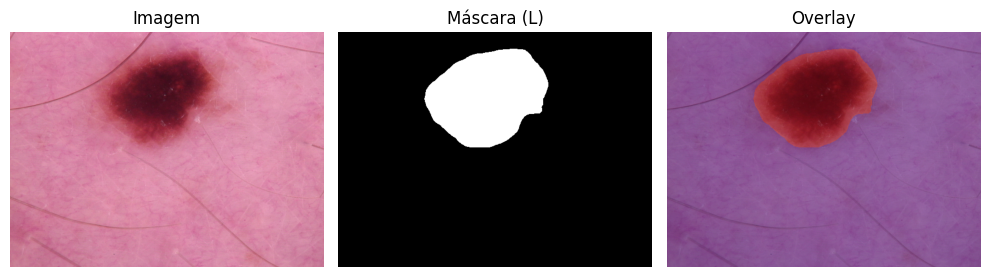

In [8]:
# =========================
# 01_eda_lesions.ipynb — Célula 09
# Visual sanity checks
# =========================

def load_rgb(path: Path) -> np.ndarray:
    im = Image.open(path).convert("RGB")
    return np.array(im)

def load_mask_l(path: Path, target_size: Optional[Tuple[int, int]] = None) -> np.ndarray:
    m = Image.open(path).convert("L")
    if target_size is not None:
        m = m.resize((target_size[1], target_size[0]), resample=Image.NEAREST)
    return np.array(m)

def image_path(stem_or_value: str) -> Optional[Path]:
    return resolve_image_path(stem_or_value)

def mask_path(stem_or_value: str) -> Optional[Path]:
    st = norm_to_stem(stem_or_value)
    return resolve_mask_path_by_stem(st) if MASKS_DIR.exists() else None

def show_sample(stem_or_value: str, alpha: float = 0.35):
    st = norm_to_stem(stem_or_value)

    img_p = image_path(st) or image_path(st + ".jpg") or image_path(st + ".png")
    if img_p is None:
        raise FileNotFoundError(f"Imagem não encontrada para stem={st}")

    img = load_rgb(img_p)
    m_p = mask_path(st)

    plt.figure(figsize=(10, 4))
    if m_p and m_p.exists():
        mask = load_mask_l(m_p, target_size=img.shape[:2])
        m_bin = (mask > 0).astype(np.uint8)

        plt.subplot(1, 3, 1)
        plt.title("Imagem")
        plt.imshow(img)
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.title("Máscara (L)")
        plt.imshow(mask, cmap="gray")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.title("Overlay")
        plt.imshow(img)
        plt.imshow(m_bin, alpha=alpha, cmap="jet")
        plt.axis("off")
    else:
        plt.title("Imagem (sem máscara resolvida)")
        plt.imshow(img)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

valid_imgs = audit_df[audit_df["image_exists"]]
if len(valid_imgs) == 0:
    raise RuntimeError("Nenhuma imagem do CSV foi resolvida no disco. Verifique a auditoria.")

if MASKS_DIR.exists():
    with_mask = valid_imgs[valid_imgs["mask_exists"]]
    pick_df = with_mask if len(with_mask) > 0 else valid_imgs
else:
    pick_df = valid_imgs

sample_stem = pick_df.sample(1, random_state=REPRO_SEED)["image_stem"].iloc[0]
print("Mostrando sample stem =", sample_stem)
show_sample(sample_stem)

In [9]:
# =========================
# 01_eda_lesions.ipynb — Célula 10
# Conclusão explícita + salvar artefatos + gate final
# =========================

def to_rel(p: Path) -> str:
    try:
        return str(p.relative_to(PROJECT_ROOT))
    except Exception:
        return str(p)

problems_found = []
if audit_images_missing > 0:
    problems_found.append(f"{audit_images_missing} imagens ausentes no disco")
if MASKS_DIR.exists() and audit_masks_missing > 0:
    problems_found.append(f"{audit_masks_missing} máscaras ausentes no disco")
if csv_dup_lines > 0:
    problems_found.append(f"{csv_dup_lines} linhas duplicadas por image_stem no CSV")
if len(disk_dup_images) > 0:
    problems_found.append(f"{len(disk_dup_images)} stems duplicados no disco (images)")
if len(disk_dup_masks) > 0:
    problems_found.append(f"{len(disk_dup_masks)} stems duplicados no disco (masks)")
if len(csv_only_images) > 0:
    problems_found.append(f"{len(csv_only_images)} stems presentes no CSV e ausentes no disco")
if len(disk_only_images) > 0:
    problems_found.append(f"{len(disk_only_images)} stems presentes no disco e ausentes no CSV")

conclusion = {
    "image_col": schema["columns"]["image_col"],
    "mask_col": schema["columns"]["mask_col"],
    "label_cols": schema["columns"]["label_cols"],
    "meta_cols": schema["columns"]["meta_cols"],
    "mask_coverage_ratio": mask_coverage_ratio if MASKS_DIR.exists() else None,
    "problems_found": problems_found,
    "notes": [
        "Se o CSV não tiver metadados úteis, meta_cols deve seguir vazio sem forçar inclusão artificial.",
        "Notebook 02 deve usar este schema como ponto de partida, mas pode ajustar o contrato final para image_stem nos CSVs preparados.",
    ],
}

schema["conclusion"] = conclusion

summary_rows = [
    ("created_at_utc", datetime.now(timezone.utc).isoformat()),
    ("project_root", str(PROJECT_ROOT)),
    ("groundtruth_csv", to_rel(GT_CSV)),
    ("images_dir", to_rel(IMAGES_DIR)),
    ("masks_dir", to_rel(MASKS_DIR)),
    ("csv_rows", int(df.shape[0])),
    ("csv_cols", int(df.shape[1])),
    ("image_files_on_disk", int(len(image_files))),
    ("mask_files_on_disk", int(len(mask_files))),
    ("image_col_inferred", str(schema["columns"]["image_col"])),
    ("mask_col_inferred", str(schema["columns"]["mask_col"])),
    ("mode_inferred", str(schema["columns"]["mode"])),
    ("target_encoding", str(schema["columns"].get("target_encoding"))),
    ("label_cols_count", int(len(schema["columns"]["label_cols"]))),
    ("meta_cols_count", int(len(schema["columns"]["meta_cols"]))),
    ("audit_total_rows", int(len(audit_df))),
    ("audit_images_missing", int(audit_images_missing)),
    ("audit_masks_missing", int(audit_masks_missing if MASKS_DIR.exists() else 0)),
    ("mask_coverage_ratio", float(mask_coverage_ratio) if MASKS_DIR.exists() else ""),
    ("disk_only_image_stems", int(len(disk_only_images))),
    ("csv_only_image_stems", int(len(csv_only_images))),
    ("csv_duplicate_stems", int(csv_dup_lines)),
    ("disk_duplicate_image_stems", int(len(disk_dup_images))),
    ("disk_duplicate_mask_stems", int(len(disk_dup_masks))),
]

eda_resumo = pd.DataFrame(summary_rows, columns=["key", "value"])

OUT_SCHEMA = PROCESSED_DIR / "eda_schema_inferido.json"
OUT_AUDIT = PROCESSED_DIR / "eda_auditoria_arquivos.csv"
OUT_RESUMO = PROCESSED_DIR / "eda_resumo.csv"

with OUT_SCHEMA.open("w", encoding="utf-8") as f:
    json.dump(schema, f, ensure_ascii=False, indent=2)

audit_df.to_csv(OUT_AUDIT, index=False, encoding="utf-8")
eda_resumo.to_csv(OUT_RESUMO, index=False, encoding="utf-8")

gate_checks = {
    "schema_saved": OUT_SCHEMA.exists(),
    "audit_saved": OUT_AUDIT.exists(),
    "summary_saved": OUT_RESUMO.exists(),
    "image_col_defined": bool(schema["columns"]["image_col"]),
    "label_cols_nonempty": len(schema["columns"]["label_cols"]) > 0,
    "audit_has_rows": len(audit_df) > 0,
    "csv_rows_match_audit_rows": len(audit_df) == len(df),
}

gate_pass = all(gate_checks.values())

print("=== Conclusão operacional ===")
print("image_col :", conclusion["image_col"])
print("mask_col  :", conclusion["mask_col"])
print("label_cols:", conclusion["label_cols"])
print("meta_cols :", conclusion["meta_cols"])
print("mask_coverage_ratio:", conclusion["mask_coverage_ratio"])
print("problems_found:", conclusion["problems_found"] if conclusion["problems_found"] else "(nenhum problema crítico)")

print("\n=== Artefatos salvos ===")
print("-", to_rel(OUT_SCHEMA))
print("-", to_rel(OUT_AUDIT))
print("-", to_rel(OUT_RESUMO))

print("\n=== Gate final ===")
for k, v in gate_checks.items():
    print(f"- {k}: {v}")
print("STATUS:", "PASS" if gate_pass else "FAIL")

display(eda_resumo)

=== Conclusão operacional ===
image_col : image
mask_col  : None
label_cols: ['mel', 'nv', 'bcc', 'akiec', 'bkl', 'df', 'vasc']
meta_cols : []
mask_coverage_ratio: 1.0
problems_found: (nenhum problema crítico)

=== Artefatos salvos ===
- data\processed\eda_schema_inferido.json
- data\processed\eda_auditoria_arquivos.csv
- data\processed\eda_resumo.csv

=== Gate final ===
- schema_saved: True
- audit_saved: True
- summary_saved: True
- image_col_defined: True
- label_cols_nonempty: True
- audit_has_rows: True
- csv_rows_match_audit_rows: True
STATUS: PASS


,key,value
0,created_at_utc,2026-04-23T16:38:02.499116+00:00
1,project_root,C:\Users\win\Documents\GitHub\pimple
2,groundtruth_csv,data\raw\lesions\GroundTruth.csv
3,images_dir,data\raw\lesions\images
4,masks_dir,data\raw\lesions\masks
5,csv_rows,10015
6,csv_cols,8
7,image_files_on_disk,10015
8,mask_files_on_disk,10015
9,image_col_inferred,image
